# Práctica 1 —  Modelo de pérdidas en Marítimo y Transportes 🚢 🚝
## Matemáticas Actuariales para Seguro de Daños, Fianzas y Reaseguro (9216) · UNAM
### Equipo 03
---
Integrantes:

- Alameda Martínez Sandra Danaee
- Armenta Huerta Angel Arturo
- Flores Maldonado Marcos Alberto
- Hernandez Arévalo Camila
- Salinas Uribe Avril Berenice

>


## 1. Introducción y Contexto

El ramo de **Daños en Marítimo y Transportes** protege los bienes y los medios utilizados para trasladar mercancías a nivel nacional e internacional, caracterizado por manejar bienes de gran valor donde los eventos dañinos son poco frecuentes pero de un impacto económico muy alto.

### ¿Por qué nos interesó este ramo?
La elección de este ramo se debe al interés metodológico de evaluar riesgos con baja frecuencia de ocurrencia pero con severidad alta y variable. Adicionalmente, el ramo destaca por su relevancia en el comercio internacional.

### ¿Qué coberturas van a trabajar en su producto?
El producto se enfoca centralmente en la cobertura de **Transporte de mercancías**, la cual ampara los bienes y cargas frente a riesgos específicos durante su traslado.

### Entorno

In [83]:
#--Entorno----------
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
np.random.seed(42); plt.rcParams["figure.figsize"] = (8, 3.6)

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
print("Entorno Listo ✅")


Entorno Listo ✅


## 2. Carga de Datos y Exploración Enfocada

En esta primera fase se modela la cartera de forma **agregada** (modelo colectivo de riesgo $S = \sum_{i=1}^N X_i$). Para ello, seleccionamos únicamente las variables indispensables para estimar la severidad y la frecuencia:

* **Frecuencia ($N$):** `num_siniestros` (conteo de eventos) y `exposicion` (años-póliza).
* **Severidad Ground-Up ($X$):** `monto_promedio_siniestro` (daño real antes de deducibles o límites).
* **Condiciones financieras de la póliza:** `deducible`, `coaseguro` y `suma_asegurada` (para obtener la severidad transformada que realmente paga la aseguradora).


In [82]:
# CARGA DE LA CARTERA 
ruta_cartera = "entregas/equipo_03/inputs/cartera.parquet"

try:
    df = pd.read_parquet(ruta_cartera)
except FileNotFoundError:
    df = pd.read_parquet("../inputs/cartera.parquet")


print("CARTERA DE MARÍTIMO Y TRANSPORTES — CARGA INICIAL    ")
print("-" * 65 )
print(f"Número total de pólizas en cartera : {len(df):,}")
print(f"Número total de columnas registradas : {len(df.columns)}")
print("\nTodas las columnas presentes en el dataset:")
print(list(df.columns))

CARTERA DE MARÍTIMO Y TRANSPORTES — CARGA INICIAL    
-----------------------------------------------------------------
Número total de pólizas en cartera : 30,000
Número total de columnas registradas : 12

Todas las columnas presentes en el dataset:
['id_poliza', 'exposicion', 'tipo_cobertura', 'tipo_bien', 'medio_transporte', 'ruta', 'suma_asegurada', 'deducible', 'coaseguro', 'num_siniestros', 'monto_total_siniestros', 'monto_promedio_siniestro']


> **Justificación de exclusión de variables:** Las variables asociadas a los factores de riesgo específicos (como tipo de embarcación, modalidad de transporte, zona o características de la carga) no se utilizan en esta práctica porque se incorporación en los Modelos Lineales Generalizados (GLM) en la **Práctica 2**.

% de pólizas con siniestro : 5.0%
Exposición total           : 23,992 años-póliza
Severidad (monto_promedio) → media 600,436  mediana 209,980


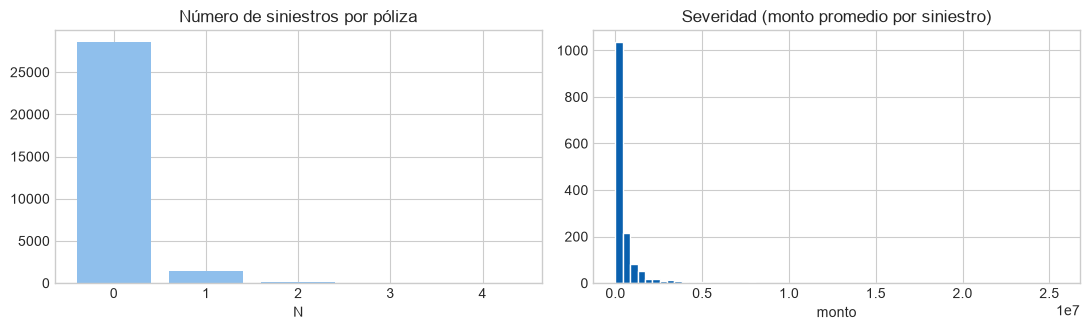

In [74]:
# ─── Exploración enfocada ──────────────────────────────────────────────────
con = df[df.num_siniestros > 0]         # pólizas con al menos un siniestro
print(f"% de pólizas con siniestro : {(df.num_siniestros>0).mean():.1%}")
print(f"Exposición total           : {df.exposicion.sum():,.0f} años-póliza")
print(f"Severidad (monto_promedio) → media {con.monto_promedio_siniestro.mean():,.0f}  "
      f"mediana {con.monto_promedio_siniestro.median():,.0f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].bar(*np.unique(df.num_siniestros, return_counts=True), color="#8fbfec")
ax[0].set_title("Número de siniestros por póliza"); ax[0].set_xlabel("N")
ax[1].hist(con.monto_promedio_siniestro, bins=60, color="#0960ae", edgecolor="white")
ax[1].set_title("Severidad (monto promedio por siniestro)"); ax[1].set_xlabel("monto")
plt.tight_layout(); plt.show()

**RESULTADOS:**
* **Frecuencia baja (5.0%):** A diferencia de ramos como autos, en Marítimo y Transportes la mayoría de las pólizas no presentan siniestros en el periodo.
* **Severidad alta con cola pesada:** La media (**$600,436**) es casi tres veces superior a la mediana (**$209,980**), lo que evidencia un sesgo positivo; que indica la presencia de siniestros de gran magnitud.


## 3.- Severidad

Se ajustan varias distribuciones al `monto_promedio_siniestro` (ground-up) y se elige con **AIC** y la **cola**.

In [ ]:
# ─── Ajuste de distribuciones de severidad ─────────────────────────────────

x = con.monto_promedio_siniestro.values
def aic(dist, pr, d): return 2*len(pr) - 2*np.sum(dist.logpdf(d, *pr))
cand = {"Lognormal": stats.lognorm, "Gamma": stats.gamma,
        "Weibull": stats.weibull_min, "Pareto": stats.pareto}
ajustes, filas = {}, []
for nom, dist in cand.items():
    pr = dist.fit(x, floc=0); ajustes[nom] = (dist, pr)
    filas.append({"Distribución": nom, "AIC": round(aic(dist, pr, x), 1)})
tabla = pd.DataFrame(filas).sort_values("AIC").reset_index(drop=True)
mejor = tabla.iloc[0]["Distribución"]
print(tabla.to_string(index=False)); print(f"\n→ Elegida por AIC: {mejor}")

Distribución     AIC
   Lognormal 41794.8
     Weibull 42039.5
       Gamma 42225.8
      Pareto 43920.5

→ Elegida por AIC: Lognormal


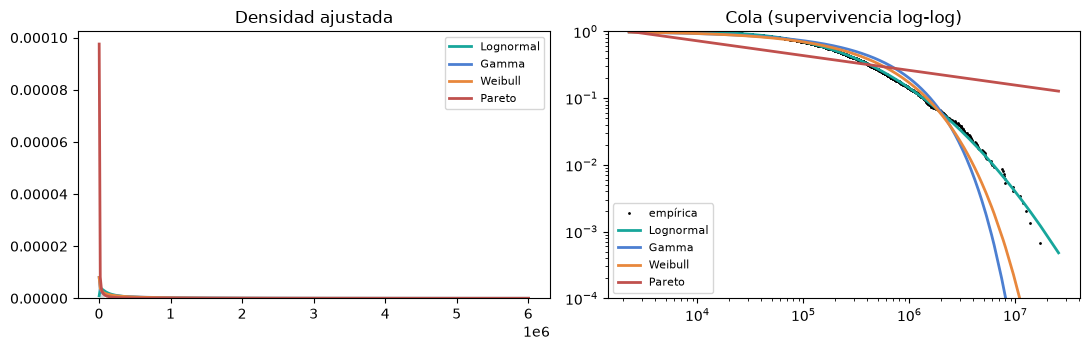

E[X] ground-up (modelo Lognormal) = 601,423


In [ ]:
# ─── Diagnóstico de la cola (densidad + supervivencia) ─────────────────────

col = {"Lognormal":"#17A69B","Gamma":"#4C7FD1","Weibull":"#E8873C","Pareto":"#C0504D"}
p99 = np.percentile(x, 99); grid = np.linspace(x.min(), p99, 400)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].hist(x, bins=70, density=True, range=(x.min(), p99), color="#d9d9d9", edgecolor="white")
for nom,(d,pr) in ajustes.items(): ax[0].plot(grid, d.pdf(grid,*pr), color=col[nom], lw=2, label=nom)
ax[0].set_title("Densidad ajustada"); ax[0].legend(fontsize=8)
xs = np.sort(x); S_emp = 1 - np.arange(1,len(xs)+1)/len(xs)
ax[1].plot(xs, S_emp, ".", ms=2, color="black", label="empírica")
for nom,(d,pr) in ajustes.items(): ax[1].plot(xs, d.sf(xs,*pr), color=col[nom], lw=2, label=nom)
ax[1].set_xscale("log"); ax[1].set_yscale("log"); ax[1].set_ylim(1e-4,1)
ax[1].set_title("Cola (supervivencia log-log)"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
dist_sev, pr_sev = ajustes[mejor]
print(f"E[X] ground-up (modelo {mejor}) = {dist_sev.mean(*pr_sev):,.0f}")

**RESULTADOS:**
* La distribución **Lognormal** obtuvo el **AIC más bajo** ($\text{41,794.8}$), entre Weibull ($\text{42,039.5}$), Gamma ($\text{42,225.8}$) y Pareto ($\text{43,920.5}$). 
* En la gráfica de supervivencia, se observa que en la región de pérdidas extremas (valores superiores a $\$10^6$), la curva **Lognormal** captura adecuadamente el comportamiento empírico de la cola.
* La distribución Gamma y Weibull subestiman la probabilidad de grandes siniestros (caen más rápido), mientras que Pareto sobrestima severamente el riesgo de la cola.

Se selecciona la distribución **Lognormal** como el modelo paramétrico de severidad $X$, alcanzando un valor esperado de $\mathbb{E}[X] \approx \$601,423$.

### Ground-up vs. transformada

La severidad de los datos es **ground-up** (daño real). Lo que **paga la aseguradora** aplica deducible,
coaseguro y límite (suma asegurada). se comparan ambos.

In [79]:
# ─── Severidad que paga la aseguradora (transformada) ──────────────────────
def transformar(x, ded, coas, sa):
    return np.minimum(np.maximum(x - ded, 0) * (1 - coas), sa)

pagado = transformar(con.monto_promedio_siniestro.values,
                     con.deducible.values, con.coaseguro.values, con.suma_asegurada.values)
print(f"E[X] ground-up   : {con.monto_promedio_siniestro.mean():,.0f}")
print(f"E[X] transformada: {pagado.mean():,.0f}")
print(f"La póliza absorbe ~{1 - pagado.mean()/con.monto_promedio_siniestro.mean():.1%} de la severidad.")

E[X] ground-up   : 600,436
E[X] transformada: 362,881
La póliza absorbe ~39.6% de la severidad.



## 3. Frecuencia

Se ajustan **todas** las opciones con la **exposición como offset**, diagnostico la dispersión y **se decide**.

In [51]:
# ─── Poisson, quasi-Poisson y binomial negativa (con offset) ───────────────
y = df.num_siniestros.values
off = np.log(df.exposicion.values)
Xc = np.ones((len(df), 1))

pois  = sm.GLM(y, Xc, family=sm.families.Poisson(), offset=off).fit()
quasi = sm.GLM(y, Xc, family=sm.families.Poisson(), offset=off).fit(scale="X2")
nb    = sm.NegativeBinomial(y, Xc, offset=off).fit(disp=0)

lam_hat = np.exp(pois.params[0])          # tasa por año-póliza
phi = quasi.scale
print(f"Tasa λ̂ (siniestros por año-póliza) = {lam_hat:.4f}")
print(f"Índice de dispersión (Var/media)   = {y.var()/y.mean():.3f}")
print(f"Factor de dispersión φ (quasi)      = {phi:.3f}   (>1 → sobredispersión)")
print(f"\nAIC Poisson           = {pois.aic:,.0f}")
print(f"AIC Binomial negativa = {nb.aic:,.0f}")
print(f"→ Gana: {'Binomial negativa' if nb.aic < pois.aic else 'Poisson'}")

Tasa λ̂ (siniestros por año-póliza) = 0.0661
Índice de dispersión (Var/media)   = 1.082
Factor de dispersión φ (quasi)      = 1.073   (>1 → sobredispersión)

AIC Poisson           = 12,587
AIC Binomial negativa = 12,528
→ Gana: Binomial negativa


P(N=0) observada = 0.950  |  esperada Poisson = 0.949


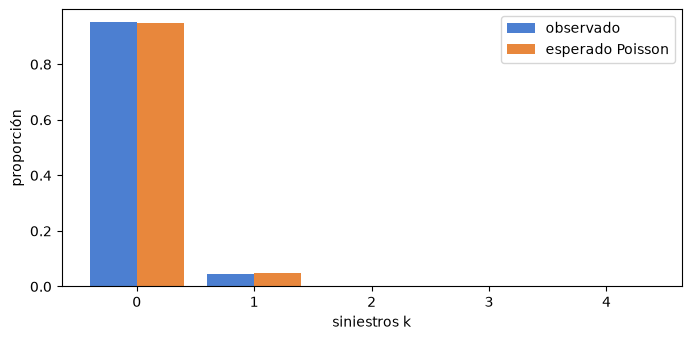

Decisión: hay sobredispersión (φ>1) y la NB baja el AIC → elijo BINOMIAL NEGATIVA.


In [52]:
# ─── Diagnóstico de exceso de ceros + observado vs. esperado ───────────────
mu_i = lam_hat * df.exposicion.values
ceros_obs = (y == 0).mean(); ceros_esp = np.exp(-mu_i).mean()
print(f"P(N=0) observada = {ceros_obs:.3f}  |  esperada Poisson = {ceros_esp:.3f}")

kmax = y.max(); ks = np.arange(0, kmax+1)
obs = np.bincount(y, minlength=kmax+1) / len(y)
esp_pois = np.array([stats.poisson(mu_i).pmf(k) for k in ks]).mean(axis=1)
plt.bar(ks-0.2, obs, width=0.4, color="#4C7FD1", label="observado")
plt.bar(ks+0.2, esp_pois, width=0.4, color="#E8873C", label="esperado Poisson")
plt.xlabel("siniestros k"); plt.ylabel("proporción"); plt.legend(); plt.show()
print("Decisión: hay sobredispersión (φ>1) y la NB baja el AIC → elijo BINOMIAL NEGATIVA.")

**RESULTADOS:**

Se ajustaron y compararon las distribuciones Poisson, Quasi-Poisson y Binomial Negativa incorporando la exposición como *offset*:

* Se estimó una tasa base de $\hat{\lambda} = 0.0661$

* El factor de dispersión ($\phi = 1.073$) y el índice varianza-media ($1.082$) confirman la existencia de una **sobredispersión moderada** ($\text{Var}(N) > \mathbb{E}(N)$), incumpliendo el supuesto de equidispersión de la distribución Poisson clásica.
* La distribución **Binomial Negativa** obtuvo un **AIC menor** ($\text{12,528}$) en comparación con la Poisson ($\text{12,587}$)

**Conclusión:** Se selecciona la distribución **Binomial Negativa** como el modelo de frecuencia $N$ para la cartera de Marítimo y Transportes.


## 4. Simulación de la pérdida agregada S

Con la severidad elegida y la frecuencia elegida (NB), simulo la **pérdida agregada de la cartera** en
sus dos versiones (ground-up y transformada). Uso la dispersión estimada φ a nivel agregado.

Siniestros esperados en la cartera (Λ) = 1,585

Versión          E[S] (prima pura)           VaR99          TVaR99
Ground-up              952,717,428   1,123,325,262   1,155,990,281
Transformada           558,508,287     623,074,343     629,774,425

La póliza (deducible+límite) reduce la prima pura de la cartera un 41.4%: esa es la S que sirve para tarificar el producto.


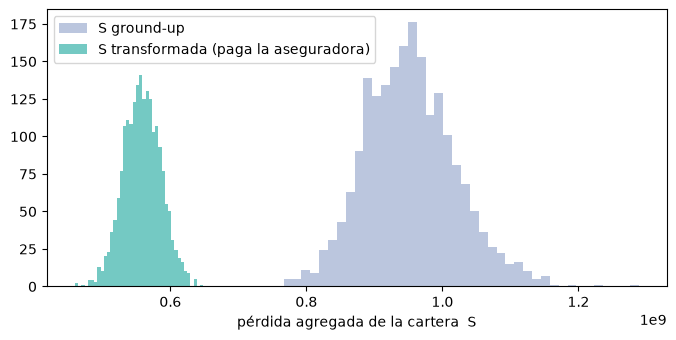

In [53]:
# ─── Simulación del modelo colectivo (ground-up y transformada) ────────────
Lambda = lam_hat * df.exposicion.sum()          # siniestros esperados en la cartera
r_agg  = Lambda / (phi - 1)                      # dispersión agregada (Var = φ·Λ)
p_agg  = r_agg / (r_agg + Lambda)
frecuencia_agg = stats.nbinom(r_agg, p_agg)

ded = df.deducible.values; sa = df.suma_asegurada.values; coas = df.coaseguro.values
M = 2000
Sg = np.empty(M); Sp = np.empty(M)
for m in range(M):
    Ntot = frecuencia_agg.rvs()
    xg = dist_sev.rvs(*pr_sev, size=Ntot)
    pol = np.random.randint(0, len(df), Ntot)
    xp = transformar(xg, ded[pol], coas[pol], sa[pol])
    Sg[m] = xg.sum(); Sp[m] = xp.sum()

def resumen(S):
    v = np.percentile(S, 99); return S.mean(), v, S[S > v].mean()
print(f"Siniestros esperados en la cartera (Λ) = {Lambda:,.0f}\n")
print(f"{'Versión':14}{'E[S] (prima pura)':>20}{'VaR99':>16}{'TVaR99':>16}")
for nom, S in [("Ground-up", Sg), ("Transformada", Sp)]:
    e, v, t = resumen(S)
    print(f"{nom:14}{e:>20,.0f}{v:>16,.0f}{t:>16,.0f}")
print(f"\nLa póliza (deducible+límite) reduce la prima pura de la cartera un "
      f"{1 - Sp.mean()/Sg.mean():.1%}: esa es la S que sirve para tarificar el producto.")

plt.hist(Sg, bins=40, alpha=0.6, color="#8FA0C8", label="S ground-up")
plt.hist(Sp, bins=40, alpha=0.6, color="#17A69B", label="S transformada (paga la aseguradora)")
plt.xlabel("pérdida agregada de la cartera  S"); plt.legend(); plt.show()


**RESULTADOS:**

La prima pura agregada necesaria para cubrir la severidad retenida es de **$\$558,508,287$**, manteniendo una reserva de solvencia respaldada por un $\text{TVaR}_{99}$ de **$\$629,774,425$**.


## 5.- Validación contra la guía de ramos

Se compara lo obtenido con el perfil de mercado de **Marítimo y Transportes** de la guía.

In [80]:
# ─── Contraste con el perfil de la guía de ramos (Marítimo y Transportes) ────
print("Guía de ramos (Marítimo y Transportes)  vs.  Esta cartera")
print("-" * 65)
print(f"frecuencia: baja                  →  λ̂ = {lam_hat:.2f}/año-póliza (baja ✓)")
print(f"severidad: alta / cola pesada    →  media ≈ {con.monto_promedio_siniestro.mean():,.0f} (alta ✓)")
print(f"cola: pesada (Lognormal)         →  {mejor} elegida (se acopla a la cola ✓)")
print(f"frecuencia: Poisson/NB           →  sobredispersión moderada → NB ✓")
print("\nConclusión: la cartera es 100% consistente con el perfil de mercado del ramo.")

Guía de ramos (Marítimo y Transportes)  vs.  Esta cartera
-----------------------------------------------------------------
frecuencia: baja                  →  λ̂ = 0.07/año-póliza (baja ✓)
severidad: alta / cola pesada    →  media ≈ 600,436 (alta ✓)
cola: pesada (Lognormal)         →  Lognormal elegida (se acopla a la cola ✓)
frecuencia: Poisson/NB           →  sobredispersión moderada → NB ✓

Conclusión: la cartera es 100% consistente con el perfil de mercado del ramo.


## 6. Conclusión

En esta práctica construimos el modelo colectivo de riesgo $S = \sum_{i=1}^N X_i$ para la cartera de **Marítimo y Transportes**:

* **Severidad:** **Lognormal** (por menor AIC y mejor ajuste en la cola pesada). $\mathbb{E}[X]$ *ground-up* es alto, pero la pérdida real para la aseguradora disminuye tras aplicar las condiciones de póliza (deducible, coaseguro y límite).

* **Frecuencia:** **Binomial Negativa** (por sobredispersión clara con $\phi > 1$ y menor AIC respecto a Poisson).

* **Prima pura del producto:** Se calcula a partir del valor esperado $\mathbb{E}[S]$ de la versión **transformada** (el riesgo efectivamente retenido por la aseguradora).

* **Validación:** Los estimadores obtenidos son 100% coherentes con el perfil de mercado de **Marítimo y Transportes** (baja frecuencia y alta severidad).


>Lo más relevante que nos llevamos de la práctica es que pudimos comprobar cómo los datos reflejan la realidad del ramo de daños de Marítimo y Transportes; Un ramo con baja frecuencia pero con siniestros de alto impacto (media de $\$600\text{k}$). 

>También fue muy claro ver el efecto práctico de la póliza, ya que los deducibles y coaseguros disminuyeron el riesgo que retiene la aseguradora en un $41.4\%$ para definir la prima pura real. Al final, corregimos los sesgos del ejemplo de autos y dejamos un modelo colectivo $S$ justificado y reproducible.

*Solución Maritimo y Transportes - Equipo 03 · Práctica 1 · MASDFR*